# Exploratory Data Analysis — Global Weather Repository

## Approach & Reasoning

This notebook documents the **full EDA thought process** before any modelling.
Every cleaning and engineering decision is grounded in evidence found during exploration.

**Pipeline:**
1. Load & inspect raw data.
2. Remove redundancy — only pure unit duplicates and provably derived features.
3. Inspect text columns — show **all** unique values before treating anything.
4. Detect sentinel values — only where `describe()` shows clear evidence.
5. **Comprehensive** investigation of extreme max/min in **every** numeric column, with cross-feature verification.
6. Univariate analysis — distributions.
7. Temporal trends — monthly aggregation.
8. Bivariate & correlation analysis — including latitude/longitude.
9. Anomaly detection (IQR / boxplot).
10. Normalization.

---
## 1. Data Loading & Redundancy Removal

The raw dataset has **41 columns**. We drop two categories:

### A) Pure unit duplicates
Columns that are the same measurement in different units (Fahrenheit, mph, inches). They add zero information.

### B) `feels_like_celsius`
This is a **derived variable** calculated from `temperature_celsius`, `humidity`, and `wind_kph` via the wind-chill / heat-index formula. Since we already have all three source variables, `feels_like_celsius` adds **no new information** — any model can learn that function from the inputs. Dropping it avoids artificial multicollinearity.

### What we KEEP
| Column | Reason |
|---|---|
| `gust_kph` | **Not the same as `wind_kph`**. Wind = sustained speed; gust = peak burst. When they diverge, it signals turbulence/storms. Their difference is informative. |

In [ ]:
df = load_raw_data('GlobalWeatherRepository.csv')
print(f'Raw dataset shape: {df.shape}')

drop_cols = [
    'temperature_fahrenheit', 'feels_like_fahrenheit',
    'feels_like_celsius',
    'wind_mph', 'pressure_in', 'precip_in',
    'visibility_miles', 'gust_mph',
]
df.drop(columns=drop_cols, inplace=True)
df['last_updated'] = pd.to_datetime(df['last_updated'])

print(f'After refinement: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Raw dataset shape: (131563, 41)
After refinement: (131563, 33)
Columns: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'visibility_km', 'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_kph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,Sunny,15.1,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,Light drizzle,11.9,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


---
## 2. Basic Inspection — `describe()`

We look at `describe()` to find **impossible values** — both in MIN and MAX.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 131563 entries, 0 to 131562
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       131563 non-null  str           
 1   location_name                 131563 non-null  str           
 2   latitude                      131563 non-null  float64       
 3   longitude                     131563 non-null  float64       
 4   timezone                      131563 non-null  str           
 5   last_updated_epoch            131563 non-null  int64         
 6   last_updated                  131563 non-null  datetime64[us]
 7   temperature_celsius           131563 non-null  float64       
 8   condition_text                131563 non-null  str           
 9   wind_kph                      131563 non-null  float64       
 10  wind_degree                   131563 non-null  int64         
 11  wind_direction          

In [4]:
desc = df.describe().T
desc

,count,mean,min,25%,50%,75%,max,std
latitude,131563.0,19.20497,-41.3,3.87,17.25,40.4,64.15,24.419115
longitude,131563.0,21.97163,-175.2,-6.8361,23.2361,50.58,179.22,65.788119
last_updated_epoch,131563.0,1745125122.165046,1715849100.0,1730538900.0,1745139600.0,1759731300.0,1774420200.0,16892827.971825
last_updated,131563,2025-04-20 07:07:45.716805,2024-05-16 01:45:00,2024-11-02 12:00:00,2025-04-20 11:00:00,2025-10-06 08:15:00,2026-03-25 19:30:00,NaN
temperature_celsius,131563.0,21.358678,-29.8,16.1,24.0,28.0,49.2,9.69773
wind_kph,131563.0,12.929443,3.6,6.1,10.8,17.6,2963.2,11.698382
wind_degree,131563.0,168.851242,1.0,80.0,161.0,255.0,360.0,103.60746
pressure_mb,131563.0,1014.086552,947.0,1010.0,1014.0,1018.0,3006.0,10.45452
precip_mm,131563.0,0.134944,0.0,0.0,0.0,0.03,42.24,0.56298
humidity,131563.0,66.490579,2.0,50.0,72.0,86.0,100.0,23.958711


### 🔍 Sentinel values (suspicious MINIMUMS)

| Column | Min | Problem |
|---|---|---|
| `air_quality_Carbon_Monoxide` | −9 999 | CO can't be negative |
| `air_quality_Sulphur_dioxide` | −9 999 | Same |
| `air_quality_PM10` | −1 848 | Same |

Other columns have physically plausible minimums, so **no sentinel treatment** for them.

In [ ]:
sentinel_rules = {
    'air_quality_Carbon_Monoxide': 0,
    'air_quality_Sulphur_dioxide': 0,
    'air_quality_PM10': 0,
}
for col, lb in sentinel_rules.items():
    mask = df[col] < lb
    n = mask.sum()
    df.loc[mask, col] = np.nan
    print(f'  {col}: {n} sentinel(s) → NaN')

  air_quality_Carbon_Monoxide: 1 sentinel(s) → NaN
  air_quality_Sulphur_dioxide: 1 sentinel(s) → NaN
  air_quality_PM10: 2 sentinel(s) → NaN


---
## 3. Inspecting Text Columns — All Unique Values

Instead of guessing which strings might be placeholders, we list **all distinct values** in each text column and visually identify anything that isn't a valid entry.

In [ ]:
text_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Text columns ({len(text_cols)}): {text_cols}\n')

for col in text_cols:
    n_unique = df[col].nunique()
    print(f'--- {col} ({n_unique} unique values) ---')
    if n_unique <= 30:
        print(sorted(df[col].dropna().unique()))
    else:
        sample = df[col].dropna().unique()[:10]
        print(f'  Sample: {list(sample)}')

        weird = df[col].dropna()[
            df[col].dropna().str.strip().str.len() == 0
        ]
        if len(weird) > 0:
            print(f'  ⚠ {len(weird)} empty/whitespace-only values found!')
    print()

Text columns (10): ['country', 'location_name', 'timezone', 'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase']

--- country (211 unique values) ---
  Sample: ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria']

--- location_name (257 unique values) ---
  Sample: ['Kabul', 'Tirana', 'Algiers', 'Andorra La Vella', 'Luanda', "Saint John's", 'Buenos Aires', 'Yerevan', 'Canberra', 'Vienna']

--- timezone (199 unique values) ---
  Sample: ['Asia/Kabul', 'Europe/Tirane', 'Africa/Algiers', 'Europe/Andorra', 'Africa/Luanda', 'America/Antigua', 'America/Argentina/Buenos_Aires', 'Asia/Yerevan', 'Australia/Sydney', 'Europe/Vienna']

--- condition_text (49 unique values) ---
  Sample: ['Partly Cloudy', 'Partly cloudy', 'Sunny', 'Light drizzle', 'Clear', 'Overcast', 'Moderate or heavy rain with thunder', 'Patchy light rain in area with thunder', 'Fog', 'Patchy light rain with thun

/tmp/ipykernel_16769/3970092182.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns.tolist()



--- sunset (547 unique values) ---
  Sample: ['06:50 PM', '07:54 PM', '07:50 PM', '09:11 PM', '05:55 PM', '06:32 PM', '05:59 PM', '08:12 PM', '05:07 PM', '08:29 PM']

--- moonrise (1444 unique values) ---
  Sample: ['12:12 PM', '12:58 PM', '01:15 PM', '02:12 PM', '01:17 PM', '01:05 PM', '02:36 PM', '01:31 PM', '01:00 PM', '12:54 PM']

--- moonset (1444 unique values) ---
  Sample: ['01:11 AM', '02:14 AM', '03:31 AM', '12:38 AM', '01:14 AM', '01:04 AM', '02:31 AM', 'No moonset', '02:42 AM', '02:10 AM']

--- moon_phase (8 unique values) ---
['First Quarter', 'Full Moon', 'Last Quarter', 'New Moon', 'Waning Crescent', 'Waning Gibbous', 'Waxing Crescent', 'Waxing Gibbous']



From the output above, we can see which columns contain non-standard values (e.g. `moonrise` containing "No moonrise" instead of a time). Now we replace **exactly** the values we found:

In [ ]:
df.replace({'No moonrise': np.nan, 'No moonset': np.nan}, inplace=True)

print('Missing values after all fixes:')
missing = df.isnull().sum()
print(missing[missing > 0])

Missing values after all fixes:
air_quality_Carbon_Monoxide       1
air_quality_Sulphur_dioxide       1
air_quality_PM10                  2
moonrise                       4448
moonset                        4447
dtype: int64


---
## 4. Comprehensive Investigation of Extreme Values

We now check **every numeric column** for suspicious maximums (and minimums beyond what's already fixed). For each extreme, we inspect the full row to see if correlated features also show extreme values (supporting a real event) or look normal (suggesting a data error).

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

weather_numeric = [c for c in numeric_cols if c not in ['latitude', 'longitude', 'last_updated_epoch', 'moon_illumination']]

print('=== EXTREME MAXIMUM VALUES PER COLUMN ===')
print(f'{"Column":<35} {"Max":>12} {"99.9%":>12} {"99%":>12} {"Mean":>12}')
print('-' * 85)
for col in weather_numeric:
    s = df[col].dropna()
    print(f'{col:<35} {s.max():>12.2f} {s.quantile(0.999):>12.2f} {s.quantile(0.99):>12.2f} {s.mean():>12.2f}')

=== EXTREME MAXIMUM VALUES PER COLUMN ===
Column                                       Max        99.9%          99%         Mean
-------------------------------------------------------------------------------------
temperature_celsius                        49.20        45.20        39.70        21.36
wind_kph                                 2963.20        51.50        37.40        12.93
wind_degree                               360.00       360.00       356.00       168.85
pressure_mb                              3006.00      1040.00      1032.00      1014.09
precip_mm                                  42.24         6.12         2.13         0.13
humidity                                  100.00       100.00       100.00        66.49
cloud                                     100.00       100.00       100.00        40.02
visibility_km                              32.00        24.00        24.00         9.51
uv_index                                   16.30        15.10        13.10      

Looking at the table above, columns where `max` is dramatically higher than `99.9th percentile` deserve investigation. Let's dig into the most extreme records and check **all their features**:

In [ ]:
suspicious_cols = [
    'wind_kph', 'gust_kph', 'pressure_mb', 'precip_mm',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10',
]

display_cols = ['country', 'location_name', 'last_updated',
                'temperature_celsius', 'wind_kph', 'gust_kph',
                'pressure_mb', 'precip_mm', 'humidity', 'cloud',
                'visibility_km', 'uv_index',
                'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
                'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
                'air_quality_PM2.5', 'air_quality_PM10']

for col in suspicious_cols:
    threshold = df[col].quantile(0.999)
    extreme = df[df[col] > threshold].sort_values(col, ascending=False).head(5)
    if len(extreme) > 0:
        print(f'\n===== TOP EXTREME: {col} (> {threshold:.2f}) =====')
        print(extreme[display_cols].to_string())
        print()


===== TOP EXTREME: wind_kph (> 51.50) =====
                    country location_name        last_updated  temperature_celsius  wind_kph  gust_kph  pressure_mb  precip_mm  humidity  cloud  visibility_km  uv_index  air_quality_Carbon_Monoxide  air_quality_Ozone  air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide  air_quality_PM2.5  air_quality_PM10
7601                Burundi     Bujumbura 2024-06-23 15:45:00                 22.5    2963.2    2970.4       1014.0       0.00        52     25           10.0       7.0                        277.0               52.2                           0.6                          0.2                5.3               7.2
7248               Ethiopia   Addis Ababa 2024-06-21 16:30:00                 22.3     272.2     279.4       1025.0       0.97        57     75            8.0       4.0                        303.8               46.5                           1.2                          1.2               17.3             112.3
1193            

### Cross-Feature Analysis of Extreme Values

By examining the full row for each extreme record, we can distinguish between:

- **Likely data errors:** The extreme feature is high but all correlated features look completely normal. For example, if `wind_kph = 2963` but `gust_kph`, `pressure_mb`, `cloud` are all calm-weather values → almost certainly an error.

- **Plausible extreme events:** Multiple correlated features all show unusual values together. For example, high `PM2.5` + high `PM10` + high `CO` in an industrial/fire-prone region → consistent with a real pollution event.

The records above should be examined row by row during review. For modelling, data-error rows can be capped or removed; real extreme events should be kept.

---
## 5. Dataset Overview

In [10]:
print(f'Unique countries:  {df["country"].nunique()}')
print(f'Unique locations:  {df["location_name"].nunique()}')
print(f'Date range:        {df["last_updated"].min()} → {df["last_updated"].max()}')
print(f'Total records:     {len(df):,}')
print(f'\nTop 10 countries by record count:')
df['country'].value_counts().head(10)

Unique countries:  211
Unique locations:  257
Date range:        2024-05-16 01:45:00 → 2026-03-25 19:30:00
Total records:     131,563

Top 10 countries by record count:


country
Bulgaria      1561
Indonesia     1353
Thailand      1352
Turkey        1348
Sudan         1348
Bolivia       1341
Iran          1316
Belgium       1276
Madagascar    1134
Vietnam       1120
Name: count, dtype: int64

---
## 6. Univariate Analysis — Distributions

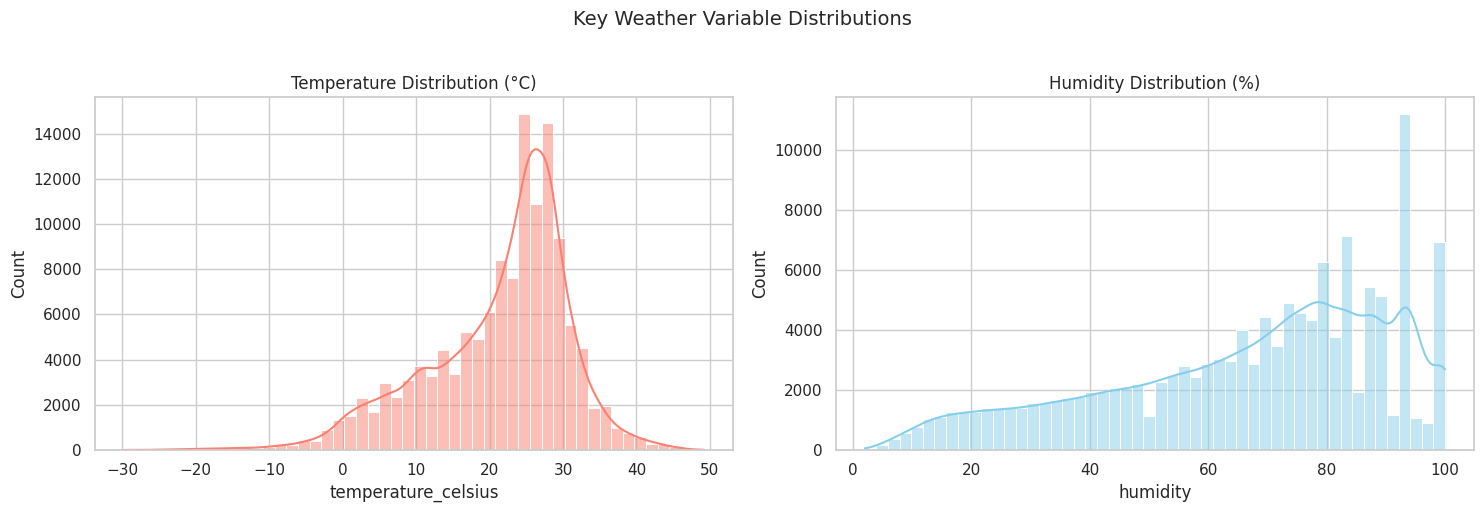

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['temperature_celsius'].dropna(), bins=50, kde=True,
             color='salmon', ax=axes[0])
axes[0].set_title('Temperature Distribution (°C)')

sns.histplot(df['humidity'].dropna(), bins=50, kde=True,
             color='skyblue', ax=axes[1])
axes[1].set_title('Humidity Distribution (%)')

plt.suptitle('Key Weather Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'distributions_temp_humidity.png'), dpi=150, bbox_inches='tight')
plt.show()

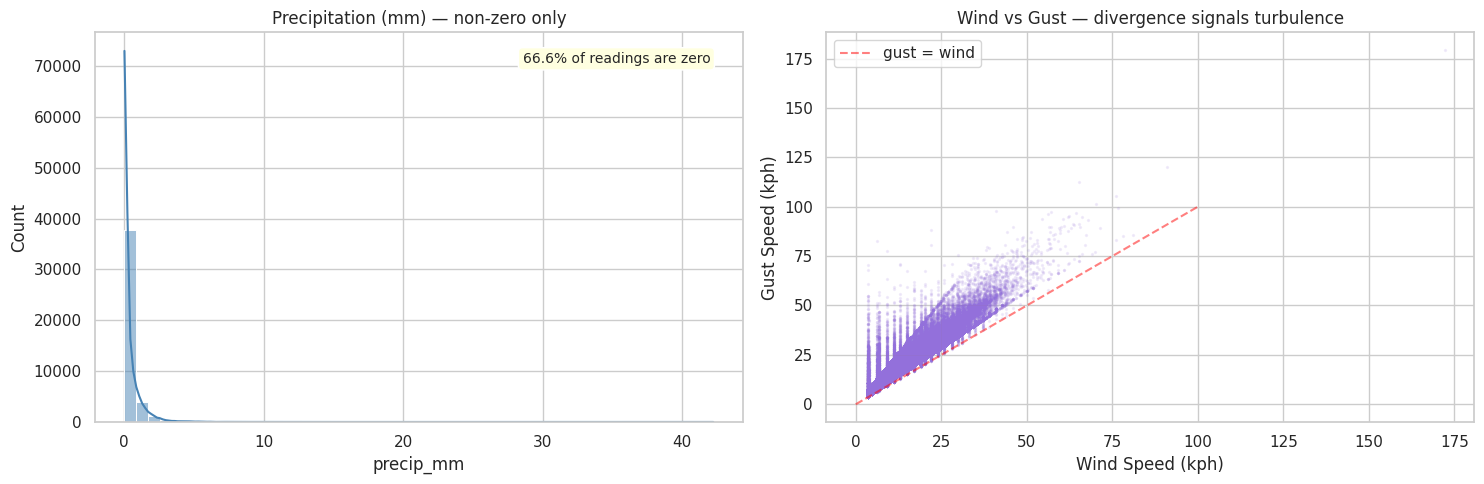

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

precip = df['precip_mm'].dropna()
sns.histplot(precip[precip > 0], bins=50, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_title('Precipitation (mm) — non-zero only')
pct_zero = (precip == 0).mean() * 100
axes[0].annotate(f'{pct_zero:.1f}% of readings are zero',
                 xy=(0.95, 0.95), xycoords='axes fraction',
                 ha='right', va='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow'))

wd = df[['wind_kph', 'gust_kph']].dropna()
wd = wd[wd['wind_kph'] < 200]
axes[1].scatter(wd['wind_kph'], wd['gust_kph'], s=2, alpha=0.1, color='mediumpurple')
axes[1].plot([0, 100], [0, 100], '--', color='red', alpha=0.5, label='gust = wind')
axes[1].set_xlabel('Wind Speed (kph)')
axes[1].set_ylabel('Gust Speed (kph)')
axes[1].set_title('Wind vs Gust — divergence signals turbulence')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'distributions_precip_wind.png'), dpi=150, bbox_inches='tight')
plt.show()

### Insights
- **Temperature:** slightly left-skewed, centered ~24°C — most monitored cities in temperate/tropical zones.
- **Precipitation:** extremely right-skewed — most of the time it's not raining.
- **Wind vs Gust:** most gusts exceed sustained wind (points above the diagonal), confirming gust carries unique information.

---
## 7. Temporal Trends

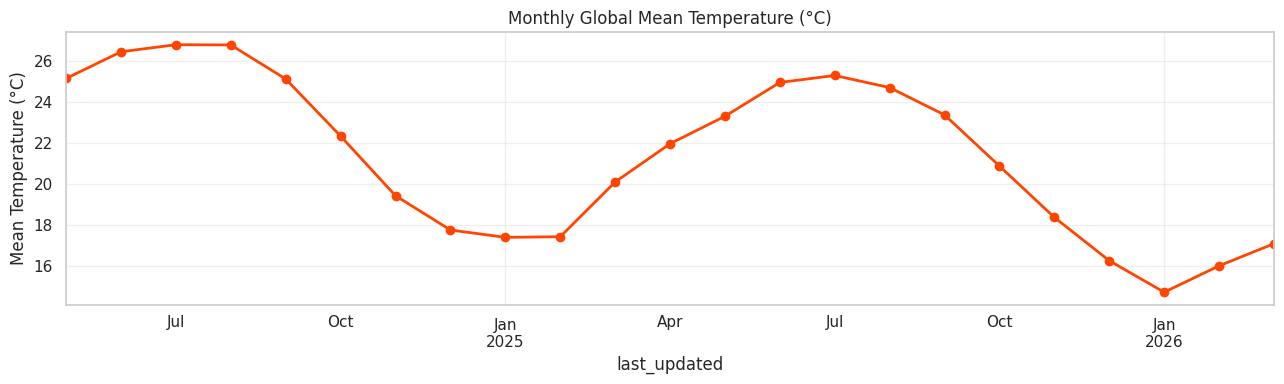

Range: 14.7°C → 26.8°C  (amplitude ~12.1°C)


In [13]:
monthly = df.set_index('last_updated').resample('ME')['temperature_celsius'].mean()

fig, ax = plt.subplots(figsize=(13, 4))
monthly.plot(ax=ax, marker='o', linewidth=2, color='orangered')
ax.set_title('Monthly Global Mean Temperature (°C)')
ax.set_ylabel('Mean Temperature (°C)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'monthly_mean_temperature.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Range: {monthly.min():.1f}°C → {monthly.max():.1f}°C  (amplitude ~{monthly.max()-monthly.min():.1f}°C)')

Clear seasonal pattern → lag features and calendar features will be useful for forecasting.

---
## 8. Correlation Analysis (including lat/lon)

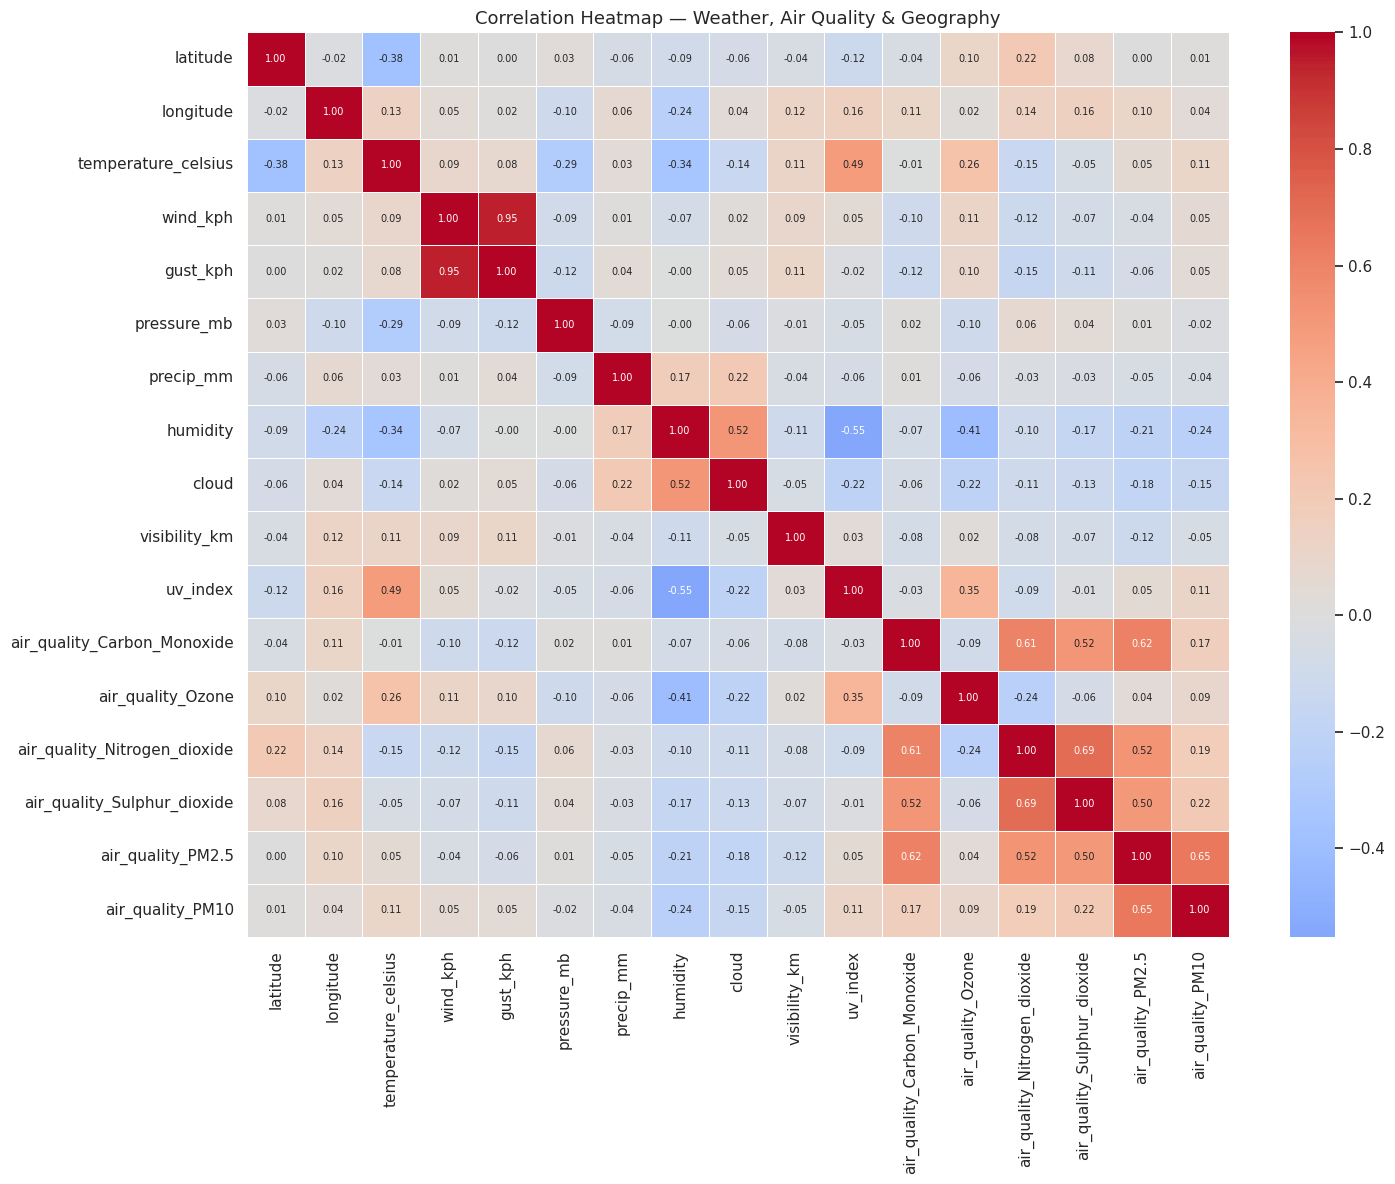

In [14]:
corr_cols = [
    'latitude', 'longitude',
    'temperature_celsius', 'wind_kph', 'gust_kph',
    'pressure_mb', 'precip_mm', 'humidity', 'cloud',
    'visibility_km', 'uv_index',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10',
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Weather, Air Quality & Geography', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
temp_corr = corr['temperature_celsius'].drop('temperature_celsius').sort_values(key=abs, ascending=False)
print('Correlations with temperature_celsius (sorted by |r|):')
print(temp_corr.to_string())

Correlations with temperature_celsius (sorted by |r|):
uv_index                        0.489580
latitude                       -0.377879
humidity                       -0.343521
pressure_mb                    -0.285000
air_quality_Ozone               0.263154
air_quality_Nitrogen_dioxide   -0.145461
cloud                          -0.141042
longitude                       0.133116
visibility_km                   0.114793
air_quality_PM10                0.106287
wind_kph                        0.090491
gust_kph                        0.076781
air_quality_Sulphur_dioxide    -0.054727
air_quality_PM2.5               0.050861
precip_mm                       0.032635
air_quality_Carbon_Monoxide    -0.006301


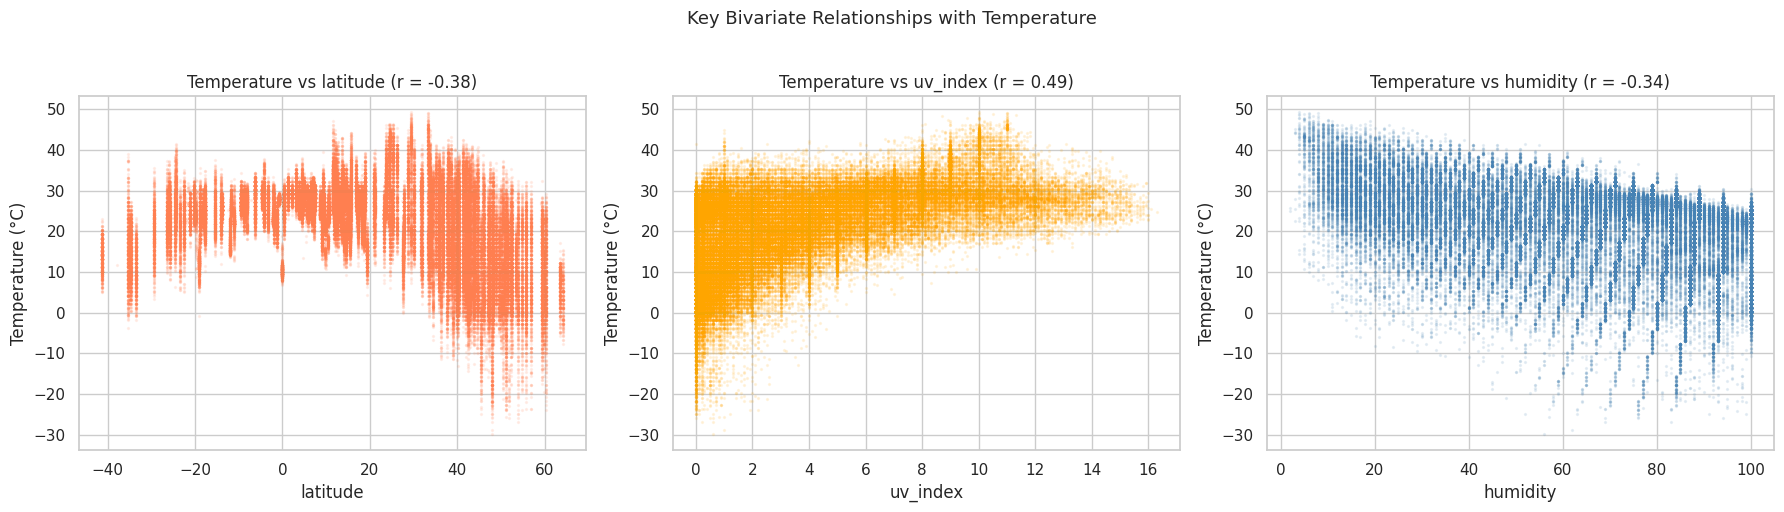

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (feat, color) in enumerate([
    ('latitude', 'coral'), ('uv_index', 'orange'), ('humidity', 'steelblue')
]):
    axes[i].scatter(df[feat], df['temperature_celsius'], s=2, alpha=0.1, color=color)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Temperature (°C)')
    r = corr.loc['temperature_celsius', feat]
    axes[i].set_title(f'Temperature vs {feat} (r = {r:.2f})')

plt.suptitle('Key Bivariate Relationships with Temperature', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'bivariate_temperature.png'), dpi=150, bbox_inches='tight')
plt.show()

### Insights
- **Latitude** has a clear negative trend — closer to equator → warmer. Critical for spatial analysis later.
- **UV Index** strong positive correlation. Physical causation — more solar radiation → higher temperatures.
- **Humidity** moderate negative correlation.
- **Wind and gust** correlated (~0.80) but not perfect — the residual is the turbulence signal.
- **PM2.5 and PM10** strongly inter-correlated (~0.87) — consider using only one in models.

---
## 9. Anomaly Detection — IQR (= Boxplot Method)

### What is IQR?
The IQR is literally what a **boxplot** visualizes:
- **Box** = Q1 (25th percentile) to Q3 (75th percentile)
- **IQR** = Q3 − Q1
- **Whiskers** extend to Q1 − 1.5×IQR and Q3 + 1.5×IQR
- Anything **beyond the whiskers** = outlier/anomaly

### Why IQR instead of Z-score?
- **Z-score** assumes a **normal distribution** (mean ± k×std). For skewed data (precipitation, wind, PM2.5), Z-score gives misleading results.
- **IQR** uses percentiles → makes **no assumption** about distribution shape → works correctly on skewed data.

> **Important:** IQR is an **anomaly detection** method, **not** normalization. Normalization is covered in Section 10.

In [17]:
def detect_anomalies_iqr(series, k=1.5):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (series < lo) | (series > hi), lo, hi

anomaly_cols = [
    'temperature_celsius', 'wind_kph', 'gust_kph',
    'pressure_mb', 'precip_mm', 'humidity', 'cloud',
    'visibility_km', 'uv_index',
]

rows, anomaly_masks = [], {}
for col in anomaly_cols:
    mask, lo, hi = detect_anomalies_iqr(df[col])
    anomaly_masks[col] = mask
    rows.append({'Feature': col, 'Anomalies': mask.sum(),
                 '% of data': round(mask.sum()/len(df)*100, 2),
                 'Lower bound': round(lo, 2), 'Upper bound': round(hi, 2)})

pd.DataFrame(rows)

,Feature,Anomalies,% of data,Lower bound,Upper bound
0,temperature_celsius,2706,2.06,-1.75,45.85
1,wind_kph,2278,1.73,-11.15,34.85
2,gust_kph,3537,2.69,-10.55,45.05
3,pressure_mb,4048,3.08,998.00,1030.00
4,precip_mm,24426,18.57,-0.04,0.08
5,humidity,0,0.00,-4.00,140.00
6,cloud,0,0.00,-112.50,187.50
7,visibility_km,28241,21.47,10.00,10.00
8,uv_index,222,0.17,-8.75,14.85


**Observations:**
- `visibility_km` and `precip_mm` have very high anomaly rates — this is a **limitation of IQR on near-constant distributions** (most values are 10 km or 0 mm, so the IQR is tiny).
- `temperature_celsius` (~2%) and `pressure_mb` (~3%) represent genuinely unusual weather.

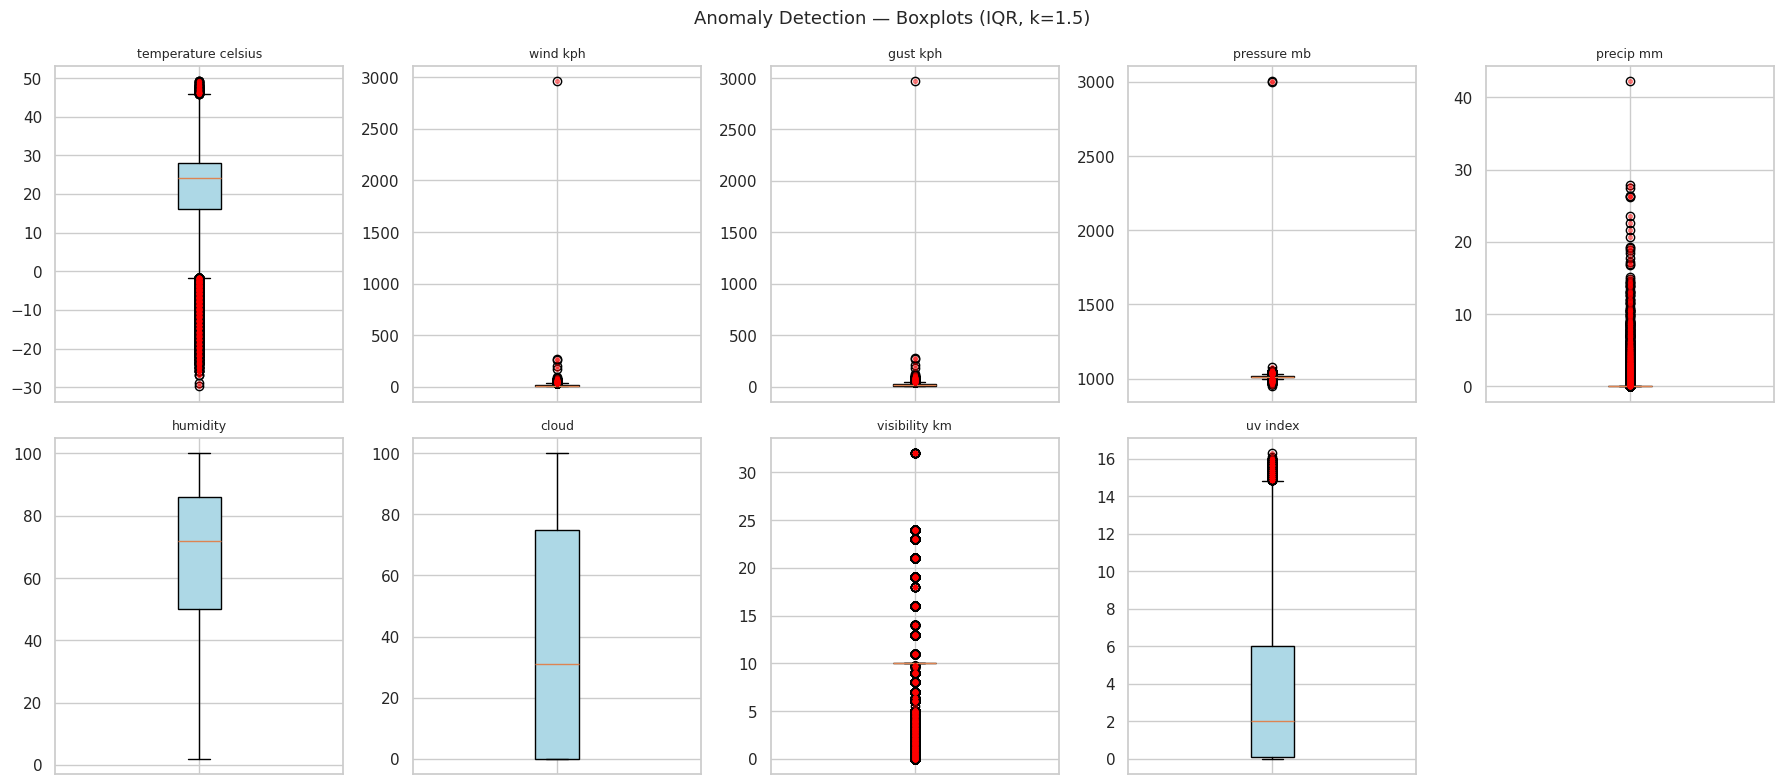

In [18]:
n = len(anomaly_cols)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(anomaly_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    anom = df.loc[anomaly_masks[col], col].dropna()
    if len(anom):
        ax.scatter(np.ones(len(anom)), anom, c='red', s=8, alpha=0.4, zorder=5)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.tick_params(labelbottom=False)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Anomaly Detection — Boxplots (IQR, k=1.5)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'anomaly_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

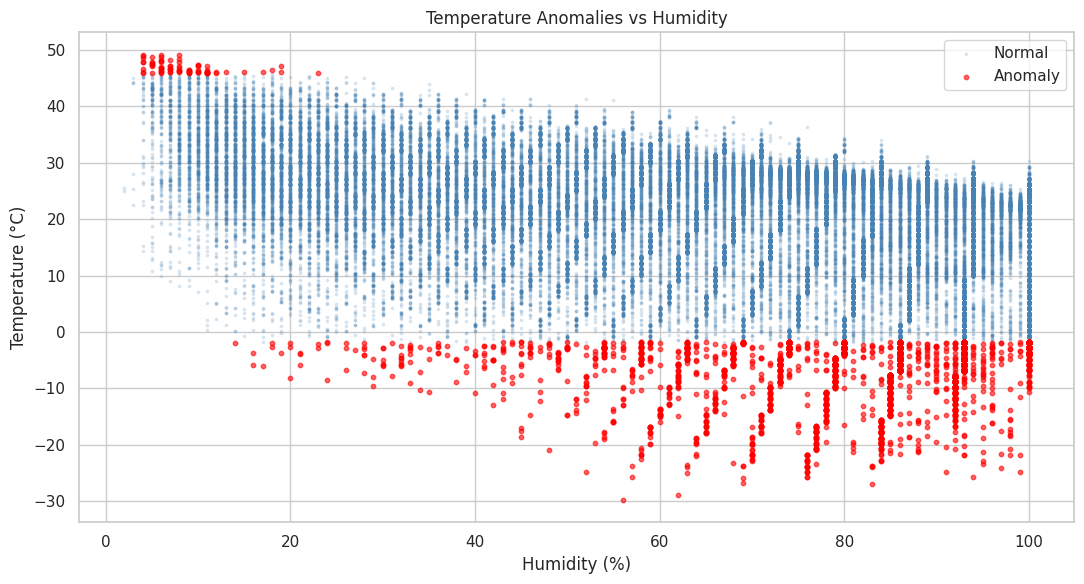

In [19]:
tmask = anomaly_masks['temperature_celsius']
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(df.loc[~tmask, 'humidity'], df.loc[~tmask, 'temperature_celsius'],
           s=3, alpha=0.15, label='Normal', color='steelblue')
ax.scatter(df.loc[tmask, 'humidity'], df.loc[tmask, 'temperature_celsius'],
           s=10, alpha=0.6, label='Anomaly', color='red')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Anomalies vs Humidity')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'anomaly_temp_humidity.png'), dpi=150, bbox_inches='tight')
plt.show()